<a href="https://colab.research.google.com/github/eogks1235-byte/DEEP_Learning-feat.Jake-Oh/blob/main/ml16_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

(주의) 분류 알고리즘

#Import


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

# Sigmoid(Logistic) 함수

$$
\phi(z) = \dfrac{e^z}{e^z + 1} = \dfrac{1}{1 + e^{-z}}
$$


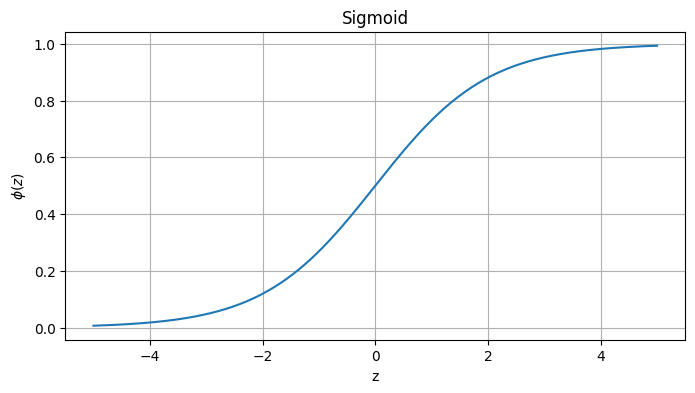

In [3]:
z = np.arange(-5, 5, 0.0001)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid)
plt.grid()
plt.title('Sigmoid')
plt.xlabel('z')
plt.ylabel(r'$\phi(z)$')
plt.show()

**Logistic Regression**

*   선형 회귀
$$
z_i = w_0 + x_{i1} \cdot w_1 + x_{i2} \cdot w_2 + \cdots = w_0 + \sum_j x_{ij} \cdot w_j
$$

*   선형 회귀 공식으로 계산된 결과를 logistic 함수의 argument로 전달
$$
p_i = \phi(z_i) = \dfrac{1}{1 + e^{-z}}
    = \dfrac{1}{1 + exp(-(w_0 + \sum_j x_{ij} \cdot w_j))}
$$

*   Sigmoid(Logistic) 함수의 리턴값은 항상 0 ~ 1이므로, Logistic Regression은 logistic 함수의 리턴값을 양성이 될 확률로 해석.
*   Logistic Regression에서 훈련(학습)이란 훈련 데이터로부터 아래의 비용 함수를 최소화하는 파라미터들($w_0$, $w_1$, ...)을 찾는 과정.

*   다중 클래스 분류에스는 softmax 함수를 클래스 $i$가 될 확률로 정의.
$$
\mathrm{softmax}{\mathbf(z)}_i = \dfrac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}}, \quad i = 1, \dots, k
$$


**비용(손실) 함수(cost/loss function)**

*   이진 분류에서는 손실 함수 log loss가 최소가 되는 계수들을 찾는 것이 목적.
*   Logistic loss function(**log loss**)

>>   $ L = -[y \log{p} + (1-y) \log{(1-p)}] $

>>   $ J(W) = - \dfrac{1}{N} \sum_{i=1}^{N} [y^{(i)} \log({p}^{(i)}) + (1-y^{(i)}) \log(1 - {p}^{(i)})] $

>>   N: the number of samples

*   다중 클래스 분류에서는 비용 함수 크로스 엔트로피가 최소가 되는 계수들을 찾는 것이 목적.
*   __Cross entropy__ cost function

>>   $ J(W) = - \dfrac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{m} y_{k}^{(i)} \log({p}_{k}^{(i)}) $

>>   N: the number of samples

>>   m: the number of classes

손실함수, 행렬식=정규방정식

인공신경망

가중치 잘 계산하면 회귀 분류 모델을만들수있다

인공지능모델들



# ANN(Artificial Neural Network, 인공 신경망)

In [6]:
from sklearn import datasets
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
import keras

In [7]:
tf.__version__

'2.19.0'

In [8]:
keras.__version__

'3.13.2'

# Iris 데이터셋



In [9]:
data, target =datasets.load_iris(return_X_y=True)

In [10]:
data.shape

(150, 4)

In [11]:
target.shape

(150,)

In [12]:
data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [14]:
#target[:5]
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# 이진 분류 (Binary classification)

* 2개의 특성만을 사용
* 0(setosa)과 0이 아닌(versicolor, virginica) 클래스로 분류


In [19]:
x = data[:, :2]

In [20]:
x[:5]

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6]])

In [22]:
y=(target!=0).astype('int')
y
# false=0, true=1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# SGD Classifier(확률적 경사하강법 분류기)

In [23]:
# loss='log_loss':logistic 손실 함수를 최소화하는 확률적 경사 하강법. 확률 >> 분류.
# max_iter=10: epoch(모든 샘플을 사용해서 경사하강법을 수행.) 횟수를 10번 제한.
sgd= SGDClassifier(loss='log_loss', random_state=42, max_iter=10, n_jobs=-1)

In [24]:
sgd.fit(X=x,y=y) # 모델 훈련 >> 손실함수를 최소로 만드는 가중치(절편과 계수들) 찾음

SGDClassifier(loss='log_loss', max_iter=10, n_jobs=-1, random_state=42)

In [26]:
sgd.coef_

array([[ 107.47482122, -163.79917975]])

In [27]:
sgd.intercept_

array([-53.41269101])

$
z= -53 + 107*x_1 + (-163 * x_2)
$

In [28]:
# SGD의 예측 확률
y_prob = sgd.predict_proba(X=x)

In [29]:
y_prob[:5]

array([[1.00000000e+00, 7.40567283e-35],
       [9.99999987e-01, 1.26753544e-08],
       [1.00000000e+00, 3.47056174e-32],
       [1.00000000e+00, 9.69472704e-30],
       [1.00000000e+00, 1.22541827e-46]])

In [30]:
y_prob[-5:]

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [32]:
# SGD 모델의 예측값
y_pred = sgd.predict(X=x)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [33]:
# SGD 모델의 정확도
accuracy_score(y_true=y,y_pred=y_pred)

0.9933333333333333

In [34]:
149/150

0.9933333333333333

# 신경망(Neural Network)

In [35]:
# 입력층(input layer)
inputs = keras.Input(shape=(2,))

In [36]:
# 출력층(output layer)
danse = keras.layers.Dense(units=1, activation='sigmoid')

In [37]:
# 신경망 모델 생성
model = keras.Sequential(layers=[inputs, danse])

In [38]:
# 생성된 신경망 모델 정보 요약
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
# 신경망 모델 컴파일: optimizer(최적화 알고리즘), loss(손실 함수), metrics(평가 기준)을 설정
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.binary_crossentropy,#log_loss
              metrics=[keras.metrics.binary_accuracy])

In [43]:
# 신경망 모델 훈련
model.fit(x=x, y=y, batch_size=1, epochs=10)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7067 - loss: 0.5493
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.7400 - loss: 0.4933
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.7600 - loss: 0.4310
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8267 - loss: 0.3964
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8800 - loss: 0.3729
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9267 - loss: 0.3358
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - binary_accuracy: 0.9400 - loss: 0.3138
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9267 - loss: 0.2977
Epoch 9/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9733 - loss: 0.2788
Epoch 10/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9667 - loss: 0.2627


In [44]:
# 신경망 모델이 학습을 통해서 찾은 모델 파라미터들(가중치, weights)
model.weights
#coeficient, intercept

[<Variable path=sequential/dense/kernel, shape=(2, 1), dtype=float32, value=[[ 1.2560467]
  [-1.9732343]]>,
 <Variable path=sequential/dense/bias, shape=(1,), dtype=float32, value=[-0.28352535]>]

In [46]:
# 신경망 모델의 예측값
y_pred = model.predict(x=x)
y_pred.shape #(n_samples, 1): 150개 샘플들의 양성(1) 예측 확률

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


(150, 1)

In [47]:
y_pred[:5]

array([[0.31345686],
       [0.48785248],
       [0.3330425 ],
       [0.3491592 ],
       [0.24844263]], dtype=float32)

In [48]:
y_pred[-5:]

array([[0.90134716],
       [0.9368188 ],
       [0.8766492 ],
       [0.68889683],
       [0.769847  ]], dtype=float32)

In [52]:
y_pred_label= (y_pred>0.5).astype('int').ravel() #ravel 2차원 배열을 1차원으로
y_pred_label

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [54]:
# 신경망 모델 평가
model.evaluate(x=x, y=y) # [loss, accuracy]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9867 - loss: 0.2466 


[0.2466268092393875, 0.9866666793823242]